# Virtual Metrology
### ECE 8803-AI4 — course notebooks

Two problem sets on virtual metrology, worked end to end. **HW1** is the Lecture 1 homework —
build the features, build the model, read it, and find the planted fault. **HW2** is the Lecture 2
homework — take that same model and find out whether it actually works.

Run the notebook from top to bottom. Each problem states what is asked, computes it from the files
in `data/`, plots the result, and then says what the result means.

**The running process.** Tool ETCH-03, poly gate etch, two chambers A and B. The response is gate
critical dimension (CD) in nanometres: target **45.0 nm**, specification **43.0 – 47.0 nm**. The
CD-SEM that measures it has a repeatability sigma of about **0.22 nm** — you will derive that number
rather than assume it.

**The data.** Twelve hundred wafers ran. Four hundred and sixty-five of them were measured.

| file | what it holds |
|---|---|
| `vm_features.csv` | one row per wafer: identifiers, chamber state, and 120 feature columns `f000`–`f119` |
| `vm_labels.csv` | the 465 CD-SEM measurements, with the tool and the time they were taken |
| `vm_events.csv` | the chamber maintenance log — cleans, with run numbers |
| `vm_traces_subset.csv` | raw 1 Hz sensor traces for 60 of the wafers, for building features yourself |
| `vm_gauge_study.csv` | a CD-SEM repeatability study: 12 wafers, 6 repeats each |
| `vm_feature_dictionary.csv` | what each `f###` column actually is |

**The three feature blocks**, because every problem below turns on them:

- `f000`–`f039` — **sensor block**. Five sensors × two recipe steps × four statistics
  (mean, standard deviation, slope, range), computed from the traces.
- `f040`–`f059` — **lot-level block**. Constant across every wafer in a lot: incoming metrology,
  queue time, a conditioning index, and lot metadata.
- `f060`–`f119` — **nuisance block**. Sixty channels that carry nothing. A real table has plenty of
  these and you do not know which in advance.

**How to read it.** Nothing is hard-coded — every number is computed from the CSVs, and the fixed
seeds mean your run reproduces exactly. If you change a split, a window or a threshold, the
conclusions move with it, which is the point.

In [1]:
# ---------------------------------------------------------------- setup
# Fetches the datasets if they are not already beside the notebook. Running the notebook
# from a clone does nothing here; opening it straight in Colab downloads the six CSVs.
from pathlib import Path
import urllib.request
from urllib.parse import quote

REPO = "aikhan123/ece8803-ai4-notebooks"
MODULE = "Module 7 Virtual Metrology"     # the module folder inside the repo
BRANCH = "main"

FILES = ["vm_features.csv", "vm_labels.csv", "vm_events.csv", "vm_traces_subset.csv",
         "vm_gauge_study.csv", "vm_feature_dictionary.csv"]

if not any((p / "vm_features.csv").exists() for p in (Path("data"), Path("../data"))):
    base = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{quote(MODULE)}/data/"
    Path("data").mkdir(exist_ok=True)
    for f in FILES:
        urllib.request.urlretrieve(base + f, Path("data") / f)
    print(f"downloaded {len(FILES)} datasets from {REPO}")
else:
    print("datasets already present — nothing to download")

datasets already present — nothing to download


In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error

# ---- locate the data directory whether the notebook is run from its own folder or above
DATA = next(p for p in (Path("data"), Path("../data"), Path("notebook/data"), Path("."))
            if (p / "vm_features.csv").exists())
print("data directory:", DATA.resolve())

# ---- process constants
LSL, USL, TGT = 43.0, 47.0, 45.0
CLEAN_RUN = 600            # the wet clean; confirmed against vm_events.csv below
N_COMP    = 8              # PLS components, the Lecture 1 model

FCOLS  = [f"f{i:03d}" for i in range(120)]
SENSOR = FCOLS[:40]
LOTLVL = FCOLS[40:60]
NUIS   = FCOLS[60:]

warnings.filterwarnings("ignore")          # LassoCV chatters about the duality gap
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (10, 3.4), "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

BLUE, GOLD, RED, GREY, TEAL = "#31708e", "#c9a227", "#c1392b", "#7f7f7f", "#5f9ea0"
BLOCK_COLOR = {"sensor": TEAL, "lot": GOLD, "nuisance": GREY}

data directory: /Users/akhan40/GaTech Dropbox/Asif Khan/Research GT/Teaching/2026/Fall 2026/ECE 8803 AI4/lecture slides/Lecture 6 SPC/notebook/ece8803-ai4-notebooks/Module 7 Virtual Metrology/data


In [3]:
def pls(k=N_COMP):
    "The Lecture 1 model: standardise inside the fold, then PLS."
    return make_pipeline(StandardScaler(), PLSRegression(n_components=k))


def cv_predict(X, y, splits, model=pls):
    "Out-of-fold predictions for any list of (train_idx, test_idx) pairs."
    pred = np.full(len(y), np.nan)
    for tr, te in splits:
        pred[te] = model().fit(X[tr], y[tr]).predict(X[te]).ravel()
    return pred


def score(y, pred):
    "R^2 and RMSE over the rows that actually received a prediction."
    ok = ~np.isnan(pred)
    return r2_score(y[ok], pred[ok]), float(np.sqrt(mean_squared_error(y[ok], pred[ok])))


def sigma_from_mr(x):
    "Short-term sigma from the average moving range of individuals, d2(2) = 1.128."
    return float(np.abs(np.diff(np.asarray(x, float))).mean() / 1.128)


def run_rules(y, cl, s):
    '''Western-Electric rules 1-4 on individuals. Returns {rule: [1-based indices]}.

    1: one point beyond 3 sigma            2: two of three beyond 2 sigma, same side
    3: four of five beyond 1 sigma, same side   4: eight in a row on one side
    '''
    y = np.asarray(y, float)
    z = (y - cl) / s
    r1 = [i + 1 for i in range(len(y)) if abs(z[i]) > 3]
    r2 = [i + 1 for i in range(2, len(y))
          if any(np.sum(z[i - 2:i + 1] > 2) >= 2 for _ in (0,))
          or np.sum(z[i - 2:i + 1] < -2) >= 2]
    r3 = [i + 1 for i in range(4, len(y))
          if np.sum(z[i - 4:i + 1] > 1) >= 4 or np.sum(z[i - 4:i + 1] < -1) >= 4]
    side, c, r4 = np.sign(z), 1, []
    for i in range(1, len(y)):
        c = c + 1 if side[i] == side[i - 1] and side[i] != 0 else 1
        if c >= 8:
            r4.append(i + 1)
    return {1: r1, 2: r2, 3: r3, 4: r4}

In [4]:
# ---------------------------------------------------------------- load everything
FEAT = pd.read_csv(DATA / "vm_features.csv", parse_dates=["timestamp"])
LABS = pd.read_csv(DATA / "vm_labels.csv", parse_dates=["measured_at"])
EVENTS = pd.read_csv(DATA / "vm_events.csv", parse_dates=["timestamp"])
TRACES = pd.read_csv(DATA / "vm_traces_subset.csv")
GAUGE = pd.read_csv(DATA / "vm_gauge_study.csv")
DICT = pd.read_csv(DATA / "vm_feature_dictionary.csv")
BLOCK = dict(zip(DICT["column"], DICT["block"]))
MEANING = dict(zip(DICT["column"], DICT["meaning"]))

print(f"features {FEAT.shape[0]} rows x {FEAT.shape[1]} cols     labels {len(LABS)}     "
      f"traces {TRACES.wafer_id.nunique()} wafers     events {len(EVENTS)}")
display(FEAT.iloc[:4, :10])
display(EVENTS)

# aborted runs first, before anything else touches the data (Lecture 1, slide 25)
n_abort = int((FEAT.recipe_complete == 0).sum())
CLEAN_FEAT = FEAT[FEAT.recipe_complete == 1].copy()
print(f"\n{n_abort} runs did not complete the recipe and are dropped: "
      f"{FEAT.loc[FEAT.recipe_complete == 0, 'wafer_id'].tolist()[:6]} ...")

# the labelled analysis frame, in run order - this is `D` for the rest of the notebook
D = (CLEAN_FEAT.merge(LABS[["wafer_id", "cd_measured_nm", "measured_at", "metrology_tool"]],
                      on="wafer_id")
     .sort_values("run_index").reset_index(drop=True))
X, y = D[FCOLS].values, D["cd_measured_nm"].values
lot, cham, run = D["lot_id"].values, D["chamber"].values, D["run_index"].values
idx, n = np.arange(len(y)), len(y)

print(f"\nlabelled wafers: {n} of {len(CLEAN_FEAT)} completed runs "
      f"({100*n/len(CLEAN_FEAT):.0f}% sampling rate)")
print(f"CD: mean {y.mean():.3f} nm, sd {y.std(ddof=1):.3f} nm, "
      f"range {y.min():.2f} - {y.max():.2f} nm, spec {LSL} - {USL}")
print(f"lots: {D.lot_id.nunique()},  chamber A {int((cham=='A').sum())} wafers, "
      f"chamber B {int((cham=='B').sum())} wafers")

# measurement delay - why you cannot simply wait for the real number
delay_h = (D.measured_at - D.timestamp).dt.total_seconds() / 3600
print(f"metrology delay: median {delay_h.median():.1f} h, "
      f"{delay_h.min():.1f} - {delay_h.max():.1f} h")

features 1200 rows x 130 cols     labels 465     traces 60 wafers     events 5


,wafer_id,lot_id,run_index,timestamp,chamber,slot,recipe,product,wafers_since_clean,f000
0,W0001,LOT01,1,2026-01-05 06:54:59.250776682,A,1,GATE-ETCH-R7,PRD-A,0,758.1096
1,W0002,LOT01,2,2026-01-05 06:59:11.250776682,A,2,GATE-ETCH-R7,PRD-A,1,758.6859
2,W0003,LOT01,3,2026-01-05 07:03:23.250776682,A,3,GATE-ETCH-R7,PRD-A,2,745.4230
3,W0004,LOT01,4,2026-01-05 07:07:35.250776682,A,4,GATE-ETCH-R7,PRD-A,3,746.4973


,event_id,run_index,timestamp,chamber,event_type,description
0,EV01,200,2026-01-06 02:31:38.354560854,A+B,dry_clean,routine in-situ chamber clean
1,EV02,400,2026-01-06 22:48:31.458926262,A+B,dry_clean,routine in-situ chamber clean
2,EV03,600,2026-01-07 19:44:26.252030130,A+B,wet_clean,wet clean and chamber kit replacement
3,EV04,800,2026-01-08 16:14:43.021775490,A+B,dry_clean,routine in-situ chamber clean
4,EV05,1000,2026-01-09 13:32:45.445253712,A+B,dry_clean,routine in-situ chamber clean



14 runs did not complete the recipe and are dropped: ['W0165', 'W0227', 'W0468', 'W0541', 'W0627', 'W0643'] ...

labelled wafers: 465 of 1186 completed runs (39% sampling rate)
CD: mean 45.233 nm, sd 0.958 nm, range 43.01 - 47.86 nm, spec 43.0 - 47.0
lots: 48,  chamber A 232 wafers, chamber B 233 wafers
metrology delay: median 4.7 h, 2.0 - 7.5 h


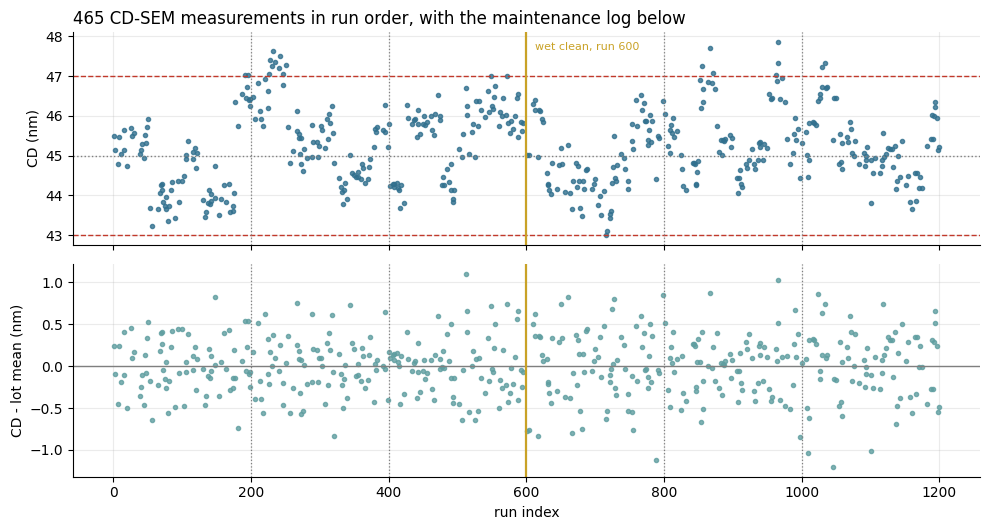

variance of CD               0.9163 nm^2
mean within-lot variance     0.1340 nm^2
share of variance that is lot-to-lot: 85.4%


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
axes[0].plot(run, y, "o", ms=3, color=BLUE, alpha=0.8)
for lim in (LSL, USL):
    axes[0].axhline(lim, color=RED, ls="--", lw=1)
axes[0].axhline(TGT, color=GREY, ls=":", lw=1)
axes[0].set_ylabel("CD (nm)")
axes[0].set_title("465 CD-SEM measurements in run order, with the maintenance log below",
                  loc="left")

lot_mean = D.groupby("lot_id")["cd_measured_nm"].transform("mean").values
axes[1].plot(run, y - lot_mean, "o", ms=3, color=TEAL, alpha=0.8)
axes[1].axhline(0, color=GREY, lw=1)
axes[1].set_ylabel("CD - lot mean (nm)"); axes[1].set_xlabel("run index")
for ax in axes:
    for _, e in EVENTS.iterrows():
        ax.axvline(e.run_index, color=GOLD if e.event_type == "wet_clean" else GREY,
                   lw=1.6 if e.event_type == "wet_clean" else 0.9,
                   ls="-" if e.event_type == "wet_clean" else ":")
axes[0].annotate("wet clean, run 600", (CLEAN_RUN, y.max()), xytext=(6, -6),
                 textcoords="offset points", fontsize=8, color=GOLD)
plt.tight_layout(); plt.show()

within = np.mean([y[lot == l].var() for l in np.unique(lot)])
print(f"variance of CD               {y.var():.4f} nm^2")
print(f"mean within-lot variance     {within:.4f} nm^2")
print(f"share of variance that is lot-to-lot: {1 - within/y.var():.1%}")

Two things are already visible, and both come back later.

The top panel wanders. It is not a stationary process — there are level changes, and one of them
sits at the wet clean on run 600.

The bottom panel is the same data with each lot's own mean removed, and it is nearly flat. Most of
the variation in CD is **between lots**, not between wafers within a lot. Any feature that tells a
model which lot a wafer came from is therefore worth a great deal to it — which is exactly the
trapdoor HW2 opens.

---
# HW1 — Build the model

**What this set covers.** Turning traces into columns, the baseline you have to beat, choosing a
model, reading what it leans on, working out the floor set by your metrology, and the housekeeping
check nobody runs.

### P1 — Build the features yourself
*Data: `vm_traces_subset.csv` (60 wafers), compared against `f000`–`f039`*

**The problem.** Segment each trace by recipe step, compute mean, standard deviation, slope and
range per step per sensor, and compare your columns against the ones supplied. They will not match
exactly. Understanding why is the point.

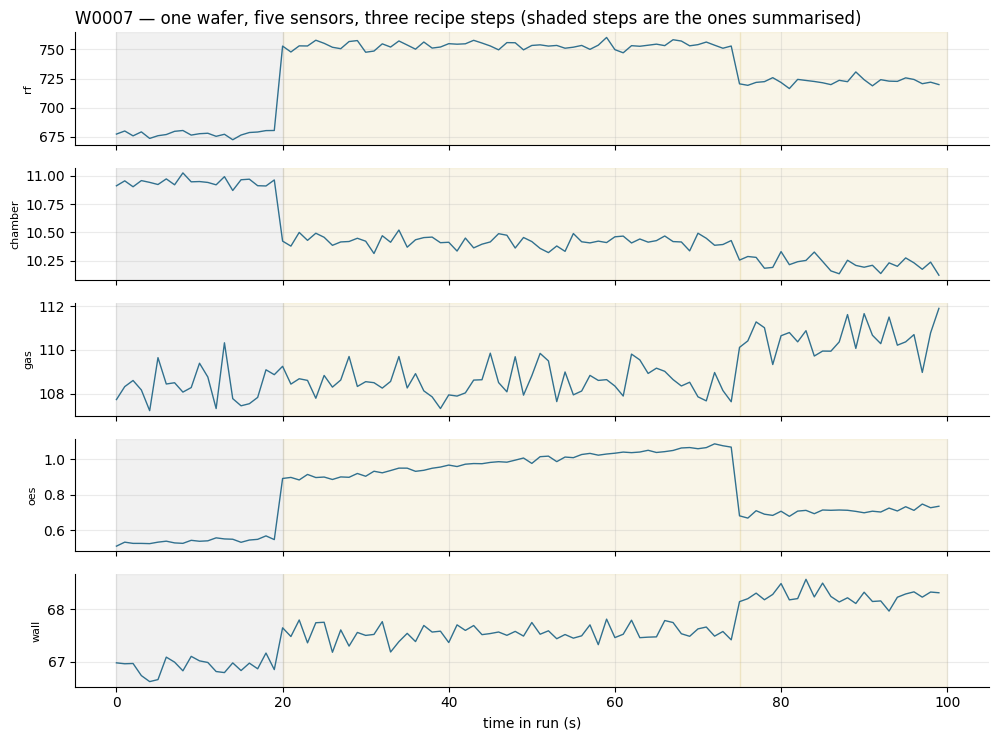

In [6]:
STEP_ORDER = ["stabilize", "main_etch", "overetch"]
SENSORS = ["rf_power_W", "chamber_pressure_mTorr", "gas_flow_sccm",
           "oes_endpoint_au", "wall_temp_C"]
SUMMARISED = ["main_etch", "overetch"]        # the two steps the supplied columns use

w0 = TRACES.wafer_id.iloc[0]
one = TRACES[TRACES.wafer_id == w0]
fig, axes = plt.subplots(5, 1, figsize=(10, 7.5), sharex=True)
for ax, s in zip(axes, SENSORS):
    ax.plot(one.t_s, one[s], lw=1, color=BLUE)
    ax.set_ylabel(s.split("_")[0], fontsize=8)
    t = 0
    for st in STEP_ORDER:
        d = int((one.step == st).sum())
        ax.axvspan(t, t + d, color=GOLD if st in SUMMARISED else GREY, alpha=0.10)
        t += d
axes[0].set_title(f"{w0} — one wafer, five sensors, three recipe steps "
                  "(shaded steps are the ones summarised)", loc="left")
axes[-1].set_xlabel("time in run (s)")
plt.tight_layout(); plt.show()

In [7]:
def summarise(df, steps=SUMMARISED, trim=0):
    "Segment by recipe step and summarise each window: mean, std, slope, range."
    rows = {}
    for wid, g in df.groupby("wafer_id", sort=True):
        vals = []
        for s in SENSORS:
            for st in steps:
                seg = g.loc[g.step == st, s].to_numpy()
                seg = seg[trim:len(seg) - trim] if trim else seg
                t = np.arange(len(seg)) - (len(seg) - 1) / 2
                slope = float((seg * t).sum() / (t ** 2).sum())
                vals += [seg.mean(), seg.std(ddof=1), slope, seg.max() - seg.min()]
        rows[wid] = vals
    cols = [f"{s}|{st}|{stat}" for s in SENSORS for st in steps
            for stat in ("mean", "std", "slope", "range")]
    return pd.DataFrame(rows, index=cols).T


mine = summarise(TRACES)
supplied = (FEAT.set_index("wafer_id").loc[mine.index, SENSOR]
            .rename(columns={c: MEANING[c] for c in SENSOR}))[mine.columns]

cmp = pd.DataFrame({
    "column": mine.columns,
    "corr": [np.corrcoef(mine[c], supplied[c])[0, 1] for c in mine.columns],
    "max |diff|": [np.abs(mine[c] - supplied[c]).max() for c in mine.columns],
    "rel err": [np.abs(mine[c] - supplied[c]).max() / (supplied[c].std() + 1e-12)
                for c in mine.columns]})
print(f"{(cmp['corr'] > 0.999).sum()} of {len(cmp)} columns reproduce to r > 0.999")
display(cmp.sort_values("rel err", ascending=False).head(8)
        .style.format({"corr": "{:.5f}", "max |diff|": "{:.4g}", "rel err": "{:.3g}"})
        .hide(axis="index"))

# now the variant a reasonable person would also have written: trim 2 s of each window
trimmed = summarise(TRACES, trim=2)
d = pd.DataFrame({
    "column": mine.columns,
    "corr with supplied": [np.corrcoef(trimmed[c], supplied[c])[0, 1] for c in mine.columns],
    "bias (nm-equivalent sd)": [(trimmed[c] - supplied[c]).mean() / (supplied[c].std() + 1e-12)
                                for c in mine.columns]})
print("\ntrimming two seconds off each window instead:")
display(d.reindex(d["corr with supplied"].abs().sort_values().index).head(6)
        .style.format({"corr with supplied": "{:.4f}", "bias (nm-equivalent sd)": "{:+.3f}"})
        .hide(axis="index"))

40 of 40 columns reproduce to r > 0.999


column,corr,max |diff|,rel err
chamber_pressure_mTorr|main_etch|slope,0.99998,4.949e-06,0.0115
oes_endpoint_au|overetch|range,1.00000,9e-05,0.00534
oes_endpoint_au|overetch|std,1.00000,1.818e-05,0.00398
chamber_pressure_mTorr|overetch|slope,1.00000,5.846e-06,0.00366
oes_endpoint_au|overetch|slope,1.00000,4.769e-06,0.00353
chamber_pressure_mTorr|main_etch|range,1.00000,0.0001,0.00338
chamber_pressure_mTorr|main_etch|std,1.00000,1.254e-05,0.00281
chamber_pressure_mTorr|overetch|std,1.00000,1.854e-05,0.00246



trimming two seconds off each window instead:


column,corr with supplied,bias (nm-equivalent sd)
wall_temp_C|overetch|slope,0.5445,-0.436
rf_power_W|overetch|slope,0.7453,+0.195
wall_temp_C|overetch|range,0.7884,-0.300
gas_flow_sccm|overetch|slope,0.7970,-0.077
chamber_pressure_mTorr|overetch|slope,0.8259,+0.108
gas_flow_sccm|overetch|range,0.8402,-0.264


### Why they do not match exactly

The means match to five decimals, because a mean over a fixed window is a mean over a fixed window.
Everything else moves:

- **Slope and range are window-sensitive.** Trim two seconds off each step and the slope changes,
  because you removed the part of the window where the ramp lives. Range changes even faster — it is
  an extreme-value statistic, so it depends on how many samples you kept.
- **Where a step begins is a decision, not a fact.** The step boundary in the log is the moment the
  recipe advanced; the chamber takes a second or two to follow. Any convention you pick is
  defensible, and none of them is the one somebody else picked.
- **`std` and `range` respond to sample rate**, so a resampled trace gives different numbers even
  with identical boundaries.

The lesson is not that one convention is right. It is that **feature definitions are part of the
model** and have to travel with it. If the trace pipeline is re-implemented in production with a
different trim, the model silently sees different inputs and gets quietly worse — with no error
anywhere and no change to the model file.

## P2 — The baseline, then three models
*Data: `vm_features.csv` + `vm_labels.csv`, 465 labelled wafers*

**The problem.** Compute the baseline **before** anything else: to predict this wafer's CD, use the
previous measured wafer's CD. Then fit ridge, lasso and PLS on the 120 columns and report random
five-fold RMSE for each. Add gradient boosting for the scoreboard.

In [8]:
# ---- the baseline: previous measured wafer, in run order
prev = np.concatenate([[y[0]], y[:-1]])
base_r2, base_rmse = score(y, prev)
print(f"baseline (previous measurement):  RMSE {base_rmse:.3f} nm   R^2 {base_r2:.3f}")

# ---- the models, all cross-validated the same way
S_RANDOM = list(KFold(5, shuffle=True, random_state=0).split(X))

MODELS = {
    "ridge":  lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 40))),
    "lasso":  lambda: make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 0, 60),
                                                              cv=5, random_state=0,
                                                              max_iter=20000)),
    f"PLS ({N_COMP} comp)": pls,
    "grad boosting": lambda: HistGradientBoostingRegressor(max_depth=3, learning_rate=0.06,
                                                           max_iter=400, random_state=0),
}
rows, PRED_RANDOM = [], {}
for name, mk in MODELS.items():
    p = cv_predict(X, y, S_RANDOM, mk)
    PRED_RANDOM[name] = p
    r2, rmse = score(y, p)
    rows.append({"model": name, "R^2": r2, "RMSE (nm)": rmse,
                 "vs baseline": 1 - rmse / base_rmse})
rows.append({"model": "baseline", "R^2": base_r2, "RMSE (nm)": base_rmse, "vs baseline": 0.0})
scoreboard = pd.DataFrame(rows)
display(scoreboard.style.format({"R^2": "{:.3f}", "RMSE (nm)": "{:.3f}",
                                 "vs baseline": "{:+.1%}"}).hide(axis="index"))

baseline (previous measurement):  RMSE 0.591 nm   R^2 0.619


model,R^2,RMSE (nm),vs baseline
ridge,0.877,0.335,+43.2%
lasso,0.865,0.352,+40.4%
PLS (8 comp),0.873,0.341,+42.3%
grad boosting,0.893,0.313,+47.0%
baseline,0.619,0.591,+0.0%


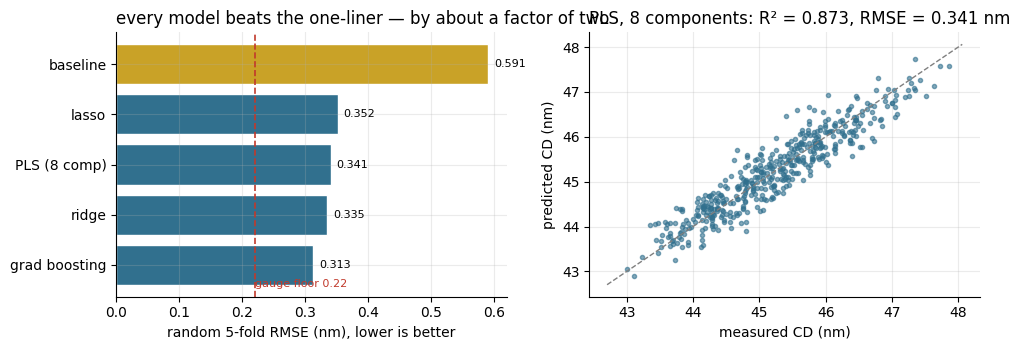

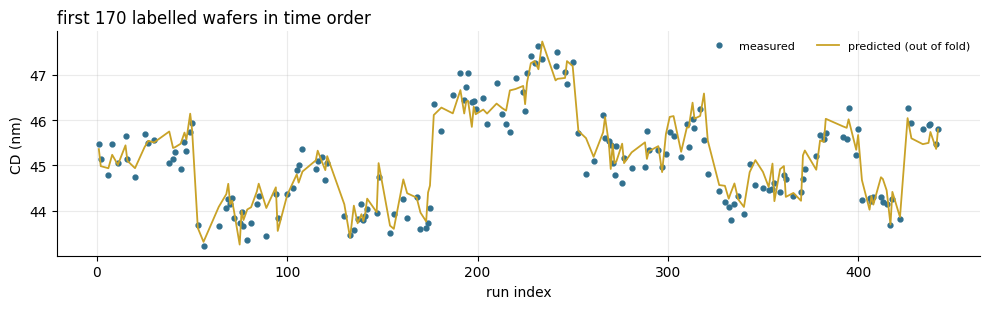

In [9]:
SIG_GAUGE_PRELIM = 0.22          # derived properly in P5

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
sb = scoreboard.sort_values("RMSE (nm)")
cols = [GOLD if m == "baseline" else BLUE for m in sb["model"]]
axes[0].barh(sb["model"], sb["RMSE (nm)"], color=cols, edgecolor="white")
axes[0].axvline(SIG_GAUGE_PRELIM, color=RED, ls="--", lw=1.2)
axes[0].annotate("gauge floor 0.22", (SIG_GAUGE_PRELIM, -0.45), color=RED, fontsize=8)
for i, v in enumerate(sb["RMSE (nm)"]):
    axes[0].annotate(f"{v:.3f}", (v, i), xytext=(4, 0), textcoords="offset points",
                     va="center", fontsize=8)
axes[0].set_xlabel("random 5-fold RMSE (nm), lower is better")
axes[0].set_title("every model beats the one-liner — by about a factor of two", loc="left")

p8 = PRED_RANDOM[f"PLS ({N_COMP} comp)"]
axes[1].plot(y, p8, "o", ms=3, alpha=0.6, color=BLUE)
lims = [min(y.min(), p8.min()) - 0.2, max(y.max(), p8.max()) + 0.2]
axes[1].plot(lims, lims, "--", color=GREY, lw=1)
r2, rmse = score(y, p8)
axes[1].set_xlabel("measured CD (nm)"); axes[1].set_ylabel("predicted CD (nm)")
axes[1].set_title(f"PLS, {N_COMP} components: R² = {r2:.3f}, RMSE = {rmse:.3f} nm", loc="left")
plt.tight_layout(); plt.show()

k = 170
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(run[:k], y[:k], "o", ms=3.5, color=BLUE, label="measured")
ax.plot(run[:k], p8[:k], lw=1.3, color=GOLD, label="predicted (out of fold)")
ax.set_xlabel("run index"); ax.set_ylabel("CD (nm)")
ax.set_title("first 170 labelled wafers in time order", loc="left")
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

### What the scoreboard says

Three observations, in order of importance.

**Every model beats the baseline by roughly a factor of two.** So there is real signal in these
traces — the sensors know something about CD that "same as last wafer" does not.

**The models are all close to each other.** Ridge, lasso and PLS land within a few percent. The
choice among them matters far less than the feature construction in P1. That is the honest lesson,
and it is not the one most machine learning courses teach.

**The error is a third of a nanometre against a four-nanometre specification window** — about 8% of
the window, and within about 1.5× of the noise of the tool we are imitating.

This is the point at which you would write the email. Hold that feeling until HW2.

## P3 — Choose the number of components, do not guess it
*Data: same 465 wafers*

**The problem.** Sweep the number of PLS components, cross-validate each, and pick one. Then
justify taking the simplest model in the flat region rather than the exact minimum — in writing.

minimum CV RMSE at 11 components (0.3366 nm)
one-standard-error threshold 0.3488 nm -> simplest model within it: 5 components (0.3464 nm)
the 8-component model used throughout costs +0.0029 nm over the minimum


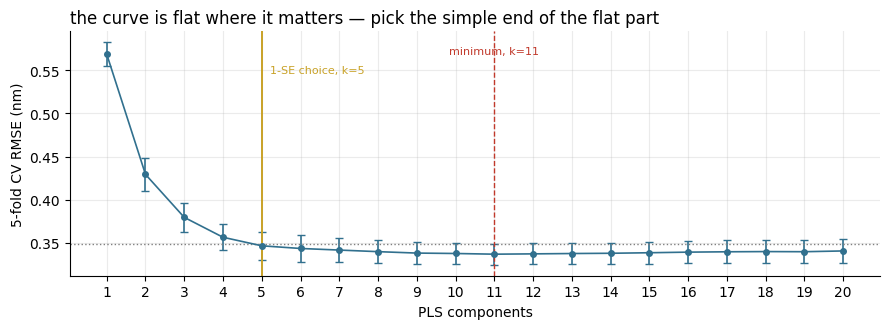

In [10]:
ks = np.arange(1, 21)
mu, se = [], []
for k in ks:
    fold_rmse = []
    for tr, te in S_RANDOM:
        m = pls(k).fit(X[tr], y[tr])
        fold_rmse.append(np.sqrt(mean_squared_error(y[te], m.predict(X[te]).ravel())))
    mu.append(np.mean(fold_rmse)); se.append(np.std(fold_rmse, ddof=1) / np.sqrt(5))
mu, se = np.array(mu), np.array(se)

k_min = ks[mu.argmin()]
thresh = mu.min() + se[mu.argmin()]
k_1se = ks[np.argmax(mu <= thresh)]
print(f"minimum CV RMSE at {k_min} components ({mu.min():.4f} nm)")
print(f"one-standard-error threshold {thresh:.4f} nm -> simplest model within it: "
      f"{k_1se} components ({mu[k_1se-1]:.4f} nm)")
print(f"the {N_COMP}-component model used throughout costs "
      f"{mu[N_COMP-1] - mu.min():+.4f} nm over the minimum")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.errorbar(ks, mu, yerr=se, marker="o", ms=4, lw=1.2, color=BLUE, capsize=3)
ax.axhline(thresh, color=GREY, ls=":", lw=1)
ax.axvline(k_min, color=RED, ls="--", lw=1)
ax.axvline(k_1se, color=GOLD, ls="-", lw=1.4)
ax.annotate(f"minimum, k={k_min}", (k_min, mu.max()), fontsize=8, color=RED, ha="center")
ax.annotate(f"1-SE choice, k={k_1se}", (k_1se, mu.max()*0.995), xytext=(6, -12),
            textcoords="offset points", fontsize=8, color=GOLD)
ax.set_xlabel("PLS components"); ax.set_ylabel("5-fold CV RMSE (nm)")
ax.set_xticks(ks)
ax.set_title("the curve is flat where it matters — pick the simple end of the flat part",
             loc="left")
plt.tight_layout(); plt.show()

### The argument, written down

The curve drops steeply for the first few components, then flattens. Inside the flat region the
differences between neighbouring values of *k* are smaller than the fold-to-fold standard error —
which means the exact minimum is a coin toss on this dataset. Rerun with a different seed and it
moves.

So the minimum is not a decision, it is noise. The **one-standard-error rule** — take the simplest
model whose CV error is within one standard error of the best — gives you a choice that is stable
across reseeds, cheaper to fit, and easier to explain.

There is a fab-specific reason on top of the statistical one. Every extra latent variable is another
direction in sensor space that the model can drift along when the chamber changes. Fewer components
is not only simpler, it is **less exposed to drift** — which is HW2's subject.

## P4 — Read the weights before you celebrate
*Data: same 465 wafers*

**The problem.** List the ten largest lasso coefficients and say which block each comes from. If the
answer is "the lot-level block", say what that implies. You will need that answer for HW2.

lasso kept 12 of 120 columns at alpha = 0.04406
kept by block: {'sensor': 7, 'lot': 5, 'nuisance': 0}


column,block,meaning,coefficient
f026,sensor,oes_endpoint_au|main_etch|slope,+0.5357
f040,lot,lot|incoming_cd_nm,+0.5007
f041,lot,lot|incoming_thk_nm,+0.1150
f035,sensor,wall_temp_C|main_etch|range,+0.0820
f050,lot,lot|meta_06,+0.0349
f031,sensor,oes_endpoint_au|overetch|range,-0.0107
f020,sensor,gas_flow_sccm|overetch|mean,+0.0103
f038,sensor,wall_temp_C|overetch|slope,+0.0099
f008,sensor,chamber_pressure_mTorr|main_etch|mean,+0.0092
f055,lot,lot|meta_11,+0.0047



share of the first PLS component's squared weight, by block: {'sensor': '49.3%', 'lot': '45.7%', 'nuisance': '5.0%'}


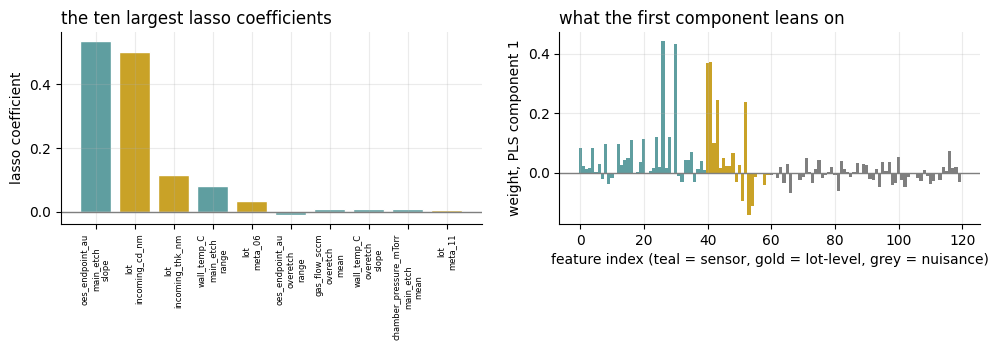

In [11]:
las = make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 0, 60), cv=5,
                                              random_state=0, max_iter=20000)).fit(X, y)
coef = pd.Series(las[-1].coef_, index=FCOLS)
nz = coef[coef != 0]
print(f"lasso kept {len(nz)} of {len(FCOLS)} columns at alpha = {las[-1].alpha_:.4g}")
print("kept by block:", {b: int(sum(BLOCK[c] == b for c in nz.index))
                         for b in ("sensor", "lot", "nuisance")})

top = coef.reindex(coef.abs().sort_values(ascending=False).index)[:10]
display(pd.DataFrame({"column": top.index, "block": [BLOCK[c] for c in top.index],
                      "meaning": [MEANING[c] for c in top.index],
                      "coefficient": top.values})
        .style.format({"coefficient": "{:+.4f}"}).hide(axis="index"))

# the same question asked of PLS: weights on the first component
pl = pls().fit(X, y)
w1 = pd.Series(pl[-1].x_weights_[:, 0], index=FCOLS)
share = {b: float((w1[[c for c in FCOLS if BLOCK[c] == b]] ** 2).sum())
         for b in ("sensor", "lot", "nuisance")}
print("\nshare of the first PLS component's squared weight, by block:",
      {k: f"{v:.1%}" for k, v in share.items()})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(range(len(top)), top.values,
            color=[BLOCK_COLOR[BLOCK[c]] for c in top.index], edgecolor="white")
axes[0].set_xticks(range(len(top)))
axes[0].set_xticklabels([MEANING[c].replace("|", "\n") for c in top.index],
                        rotation=90, fontsize=6)
axes[0].axhline(0, color=GREY, lw=1)
axes[0].set_ylabel("lasso coefficient")
axes[0].set_title("the ten largest lasso coefficients", loc="left")

axes[1].bar(range(120), w1.values,
            color=[BLOCK_COLOR[BLOCK[c]] for c in FCOLS], width=1.0)
axes[1].axhline(0, color=GREY, lw=1)
axes[1].set_xlabel("feature index (teal = sensor, gold = lot-level, grey = nuisance)")
axes[1].set_ylabel("weight, PLS component 1")
axes[1].set_title("what the first component leans on", loc="left")
plt.tight_layout(); plt.show()

### What it implies

The nuisance block is quiet — sixty columns of noise, correctly ignored. That is reassuring, and it
is the easy half of the answer.

The hard half is the gold block. **The lot-level features dominate**, and a lot-level feature is
identical for all twenty-five wafers in a lot. So ask the question that matters: if a column has the
same value for every wafer in a lot, what is it telling the model about *this* wafer?

It is telling the model **which lot this is**. And a five-fold shuffle puts other wafers from the
same lot — with their measured CDs — in the training set. Some of that impressive R² is therefore
the model recognising a lot rather than predicting a wafer.

Two honest caveats before HW2 unpicks it. Some lot-level columns are genuinely causal — incoming CD
and incoming thickness really do set where the lot lands, and a model *should* use them. And lasso
is unstable under correlated columns: it picks one of a correlated pair somewhat arbitrarily, so
treat the selected list as indicative rather than definitive. The reason to look at the list anyway
is that it is a conversation you can have with a process engineer. Twenty named columns get
questioned; nine thousand get admired and ignored.

## P5 — The floor your metrology sets
*Data: `vm_gauge_study.csv` — 12 wafers, 6 repeat measurements each*

**The problem.** Derive — do not assume — the smallest RMSE any model could achieve on these labels,
and the corresponding ceiling on R². Then say how close the model got.

gauge repeatability sigma = 0.220 nm  (75 degrees of freedom, 15 wafers x 6 repeats)

observed CD variance      0.9183 nm^2
gauge variance            0.0484 nm^2  (5.3% of it)
RMSE floor  = sigma_gauge = 0.220 nm
R^2 ceiling = 1 - sigma_gauge^2 / var(y) = 0.947

our PLS model:  RMSE 0.341 nm = 1.55x the gauge, R^2 0.873 against a ceiling of 0.947
model's own error = sqrt(0.341^2 - 0.220^2) = 0.260 nm


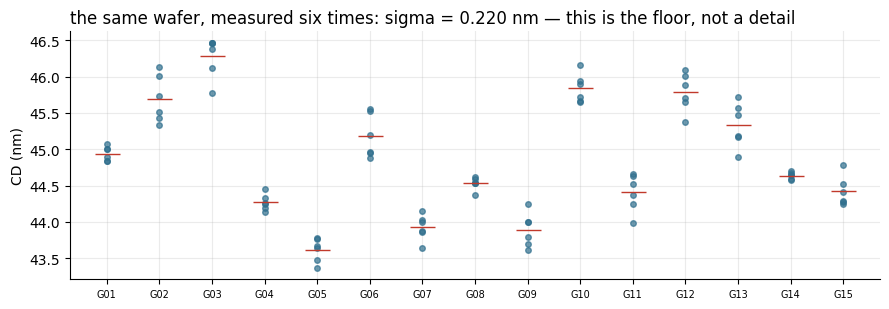

In [12]:
# repeatability: pooled within-wafer standard deviation of the repeats
g = GAUGE.groupby("study_wafer")["cd_measured_nm"]
sig_gauge = float(np.sqrt(((g.count() - 1) * g.var()).sum() / (g.count() - 1).sum()))
dof = int((g.count() - 1).sum())
print(f"gauge repeatability sigma = {sig_gauge:.3f} nm  ({dof} degrees of freedom, "
      f"{GAUGE.study_wafer.nunique()} wafers x {int(GAUGE.groupby('study_wafer').size().mean())} repeats)")

var_obs = y.var(ddof=1)
r2_ceiling = 1 - sig_gauge ** 2 / var_obs
print(f"\nobserved CD variance      {var_obs:.4f} nm^2")
print(f"gauge variance            {sig_gauge**2:.4f} nm^2  "
      f"({sig_gauge**2/var_obs:.1%} of it)")
print(f"RMSE floor  = sigma_gauge = {sig_gauge:.3f} nm")
print(f"R^2 ceiling = 1 - sigma_gauge^2 / var(y) = {r2_ceiling:.3f}")

r2_pls, rmse_pls = score(y, PRED_RANDOM[f"PLS ({N_COMP} comp)"])
print(f"\nour PLS model:  RMSE {rmse_pls:.3f} nm = {rmse_pls/sig_gauge:.2f}x the gauge, "
      f"R^2 {r2_pls:.3f} against a ceiling of {r2_ceiling:.3f}")
print(f"model's own error = sqrt({rmse_pls:.3f}^2 - {sig_gauge:.3f}^2) = "
      f"{np.sqrt(max(rmse_pls**2 - sig_gauge**2, 0)):.3f} nm")

fig, ax = plt.subplots(figsize=(9, 3.2))
for i, (w, gg) in enumerate(GAUGE.groupby("study_wafer")):
    ax.plot([i] * len(gg), gg.cd_measured_nm, "o", ms=4, color=BLUE, alpha=0.7)
    ax.plot([i], [gg.cd_measured_nm.mean()], "_", ms=18, color=RED)
ax.set_xticks(range(GAUGE.study_wafer.nunique()))
ax.set_xticklabels(sorted(GAUGE.study_wafer.unique()), fontsize=7)
ax.set_ylabel("CD (nm)")
ax.set_title(f"the same wafer, measured six times: sigma = {sig_gauge:.3f} nm "
             "— this is the floor, not a detail", loc="left")
plt.tight_layout(); plt.show()

### The derivation, in one line

A label is not the true CD. It is the true CD plus a gauge error that was generated **after** the
physics, inside the metrology tool, independently of everything the sensors saw. A model can at best
predict the true CD exactly — and it will still miss every label by exactly the amount the gauge
missed it. So

$$\text{RMSE}_{\min}=\sigma_{\text{gauge}}, \qquad R^2_{\max}=1-\frac{\sigma^2_{\text{gauge}}}{\sigma^2_{\text{observed}}}$$

Two consequences worth writing on the wall.

**An R² above the ceiling is a bug, not a triumph.** It is a diagnostic you can run on anybody's
result, including your own.

**The gap between your R² and the ceiling is the only part modelling can attack.** Everything else
is bought with a better gauge, or by averaging several measurements per wafer — which raises the
ceiling for every model anyone will ever fit on this response.

## P6 — The check nobody runs
*Data: `vm_features.csv`, all 1200 rows*

**The problem.** One sensor stops varying partway through the record. Find it, and find the run
where it stops. Three lines of code — and the reason to run them is that a stuck sensor looks
perfectly healthy on a plot.

columns whose rolling standard deviation collapses to zero: 8
['f032', 'f033', 'f034', 'f035', 'f036', 'f037', 'f038', 'f039']
all from: ['wall_temp_C']

first frozen run: 780  (414 of 1186 rows affected, 35%)
a one-off variance check over the whole history would not have caught it:
  full-history sd of f032: 1.5393  (looks alive)
  sd after run 780:            1.423e-14


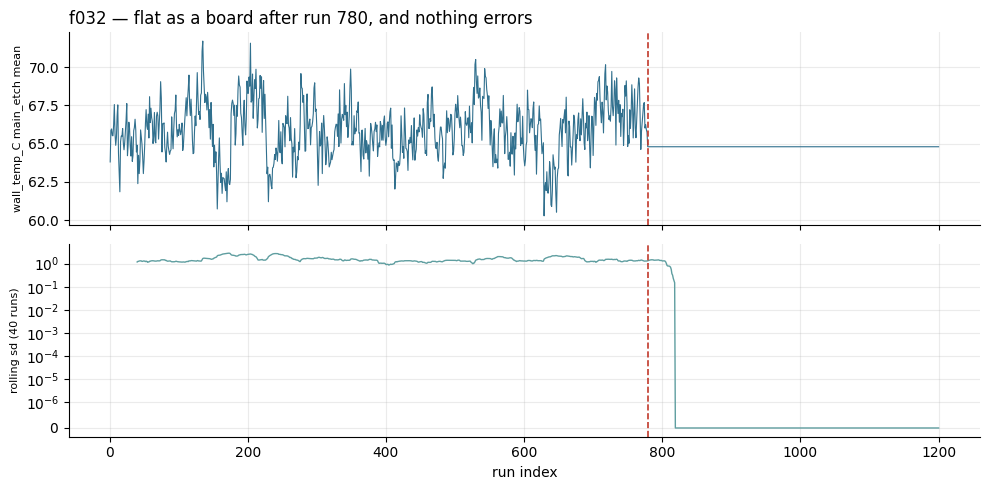

In [13]:
W = 40                                          # rolling window, in runs
roll = CLEAN_FEAT.set_index("run_index")[FCOLS].rolling(W).std()
dead_frac = (roll < 1e-9).mean()
dead_cols = dead_frac[dead_frac > 0.05].index.tolist()
print(f"columns whose rolling standard deviation collapses to zero: {len(dead_cols)}")
print(dead_cols)
print("all from:", sorted({MEANING[c].split('|')[0] for c in dead_cols}))

first_dead = {}
for c in dead_cols:
    z = roll[c] < 1e-9
    first_dead[c] = int(z[z].index[0] - W + 1)      # first run of the frozen window
stop_run = int(min(first_dead.values()))
print(f"\nfirst frozen run: {stop_run}  "
      f"({(CLEAN_FEAT.run_index >= stop_run).sum()} of {len(CLEAN_FEAT)} rows affected, "
      f"{100*(CLEAN_FEAT.run_index >= stop_run).sum()/len(CLEAN_FEAT):.0f}%)")
print("a one-off variance check over the whole history would not have caught it:")
whole = CLEAN_FEAT[dead_cols].std()
print(f"  full-history sd of {dead_cols[0]}: {whole.iloc[0]:.4f}  (looks alive)")
print(f"  sd after run {stop_run}:            "
      f"{CLEAN_FEAT.loc[CLEAN_FEAT.run_index >= stop_run, dead_cols[0]].std():.4g}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
c0 = dead_cols[0]
axes[0].plot(CLEAN_FEAT.run_index, CLEAN_FEAT[c0], lw=0.8, color=BLUE)
axes[0].set_ylabel(MEANING[c0].replace("|", " "), fontsize=8)
axes[0].set_title(f"{c0} — flat as a board after run {stop_run}, and nothing errors", loc="left")
axes[1].plot(roll.index, roll[c0], lw=1, color=TEAL)
axes[1].set_yscale("symlog", linthresh=1e-6)
axes[1].set_ylabel(f"rolling sd ({W} runs)", fontsize=8)
axes[1].set_xlabel("run index")
for ax in axes:
    ax.axvline(stop_run, color=RED, ls="--", lw=1.2)
plt.tight_layout(); plt.show()

### Why this check earns its place

The readback latched: from that run onward the tool reports the same numbers for that sensor on
every wafer. The trace still looks like a trace. The column still has a healthy standard deviation
*over the whole history*, which is why a one-off check at project start passes. The failure only
shows up in a **rolling** window — the sensor that was fine for six months and died in July.

Two practical consequences.

A frozen column carries zero information, so any model leaning on it is quietly running on fewer
features than you think. Here it happens to be a nuisance-block sensor, so nothing measurable
breaks; if it had been an endpoint channel, the model would have degraded from that run on with no
alarm anywhere.

And it is a data-quality monitor you can automate: rolling variance per column, per week, with a
threshold. It costs nothing and it catches the failure mode that no cross-validation can see.

---
# HW2 — Find out whether it works

**What this set covers.** The same model, unchanged, evaluated honestly. Nothing below refits a
better model; every number comes from changing the question rather than the answer.

### P1 — Re-evaluate the same model four ways
*Data: same 465 wafers, same PLS model, same 8 components*

**The problem.** Evaluate the Lecture 1 model four ways — random 5-fold, lot-grouped 5-fold,
leave-one-chamber-out, and a time-ordered split — and report R² and RMSE for each. Then explain
each gap. The explanations carry the marks, not the table.

In [14]:
S_LOT  = list(GroupKFold(5).split(X, y, lot))
CUT    = int(n * 0.58)                       # train on the first 58% of labelled wafers
S_TIME = [(idx[:CUT], idx[CUT:])]
A, B   = idx[cham == "A"], idx[cham == "B"]
S_LOCO = [(A, B), (B, A)]

SPLITS = {"random 5-fold": S_RANDOM, "lot-grouped 5-fold": S_LOT,
          "leave-one-chamber-out": S_LOCO, "time-ordered (58%)": S_TIME}
REMOVED = {"random 5-fold": "nothing — the Lecture 1 number",
           "lot-grouped 5-fold": "lot leakage",
           "leave-one-chamber-out": "chamber transfer",
           "time-ordered (58%)": "lot leakage and temporal leakage"}

PRED, res = {}, []
for name, sp in SPLITS.items():
    p = cv_predict(X, y, sp)
    PRED[name] = p
    r2, rmse = score(y, p)
    res.append({"split": name, "R^2": r2, "RMSE (nm)": rmse, "what it removed": REMOVED[name]})
four = pd.DataFrame(res)
display(four.style.format({"R^2": "{:.3f}", "RMSE (nm)": "{:.3f}"}).hide(axis="index"))

print(f"train/test boundary of the time-ordered split: run {run[CUT-1]} -> {run[CUT]} "
      f"({CUT} train, {n-CUT} test)")
tr_ev = EVENTS[EVENTS.run_index <= run[CUT-1]]
te_ev = EVENTS[EVENTS.run_index > run[CUT-1]]
print(f"maintenance inside the training window: {list(tr_ev.run_index)} "
      f"({', '.join(tr_ev.event_type)})")
print(f"maintenance inside the test window:     {list(te_ev.run_index)} "
      f"({', '.join(te_ev.event_type)})")
print(f"\nR² falls {four['R^2'].iloc[0]:.3f} -> {four['R^2'].iloc[3]:.3f}; "
      f"RMSE rises {four['RMSE (nm)'].iloc[0]:.3f} -> {four['RMSE (nm)'].iloc[3]:.3f} nm "
      f"({four['RMSE (nm)'].iloc[3]/four['RMSE (nm)'].iloc[0]-1:+.0%})")

split,R^2,RMSE (nm),what it removed
random 5-fold,0.873,0.341,nothing — the Lecture 1 number
lot-grouped 5-fold,0.729,0.498,lot leakage
leave-one-chamber-out,0.691,0.532,chamber transfer
time-ordered (58%),0.627,0.554,lot leakage and temporal leakage


train/test boundary of the time-ordered split: run 698 -> 699 (269 train, 196 test)
maintenance inside the training window: [200, 400, 600] (dry_clean, dry_clean, wet_clean)
maintenance inside the test window:     [800, 1000] (dry_clean, dry_clean)

R² falls 0.873 -> 0.627; RMSE rises 0.341 -> 0.554 nm (+63%)


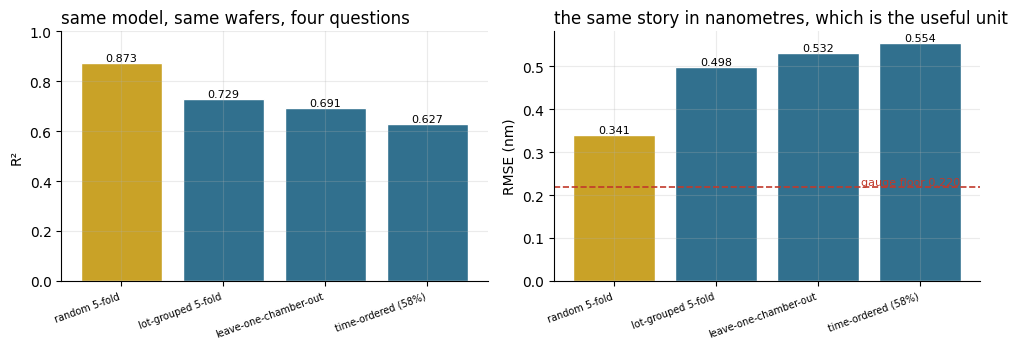

'predict the lot mean' alone:      R² 0.854
lot-level columns that are constant within a lot: 20 of 20

trained on pre-clean wafers only:
  held-out pre-clean   RMSE 0.476 nm
  after the wet clean  RMSE 0.652 nm   (+37%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
names = four["split"].tolist()
cols = [GOLD] + [BLUE] * 3
axes[0].bar(range(4), four["R^2"], color=cols, edgecolor="white")
for i, v in enumerate(four["R^2"]):
    axes[0].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=8)
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(names, rotation=20, ha="right", fontsize=7)
axes[0].set_ylabel("R²"); axes[0].set_ylim(0, 1.0)
axes[0].set_title("same model, same wafers, four questions", loc="left")

axes[1].bar(range(4), four["RMSE (nm)"], color=cols, edgecolor="white")
axes[1].axhline(sig_gauge, color=RED, ls="--", lw=1.2)
axes[1].annotate(f"gauge floor {sig_gauge:.3f}", (3.4, sig_gauge), ha="right", va="bottom",
                 fontsize=8, color=RED)
for i, v in enumerate(four["RMSE (nm)"]):
    axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(names, rotation=20, ha="right", fontsize=7)
axes[1].set_ylabel("RMSE (nm)")
axes[1].set_title("the same story in nanometres, which is the useful unit", loc="left")
plt.tight_layout(); plt.show()

# the evidence for leak one: how much of CD the lot mean alone explains
lot_only = D.groupby("lot_id")["cd_measured_nm"].transform("mean").values
print(f"'predict the lot mean' alone:      R² {r2_score(y, lot_only):.3f}")
print(f"lot-level columns that are constant within a lot: "
      f"{sum(D.groupby('lot_id')[c].nunique().max() == 1 for c in LOTLVL)} of {len(LOTLVL)}")

# the evidence for leak two: train pre-clean, test either side
pre  = idx[run <= CLEAN_RUN]
post = idx[run >  CLEAN_RUN]
kk = int(len(pre) * 0.8)
m_pre = pls().fit(X[pre[:kk]], y[pre[:kk]])
r_ho   = y[pre[kk:]] - m_pre.predict(X[pre[kk:]]).ravel()
r_post = y[post]     - m_pre.predict(X[post]).ravel()
print(f"\ntrained on pre-clean wafers only:")
print(f"  held-out pre-clean   RMSE {np.sqrt((r_ho**2).mean()):.3f} nm")
print(f"  after the wet clean  RMSE {np.sqrt((r_post**2).mean()):.3f} nm   "
      f"({np.sqrt((r_post**2).mean())/np.sqrt((r_ho**2).mean())-1:+.0%})")

### Explaining each gap — this is where the marks are

**Random → lot-grouped.** Twenty of the 120 columns are constant within a lot. Under a shuffled
split, wafers from the same lot sit on both sides of the fold boundary, so those columns work as a
lookup key for the lot mean — and the printout above shows the lot mean alone explains most of the
variance in CD. Remove the lot overlap and you remove the lookup. That is leak one, and P4 of HW1
already showed you the model leaning on it.

**Lot-grouped → time-ordered.** This is the additional cost of respecting time. Every clean
changes the chamber it leaves behind — the wet clean at run 600 most of all, which stripped polymer
from the walls and moved the mapping from sensor readings to CD. The printout above shows the same
model losing about half again in accuracy across that boundary, and it shows that the test window of
the time-ordered split contains maintenance the training window never saw.

A lot-grouped split still lets the model train on wafers from every regime and test on wafers from
every regime, so it learns an average of them and is scored on that same average. A time-ordered
split forces it to extrapolate forward into a chamber state that did not exist when it was fitted —
which is the only thing it will ever be asked to do in production.

**Leave-one-chamber-out.** Train on A, predict B, and the other way round. Each chamber has its own
sensor signature, so the model carries an offset when it moves — and it is also fitted on half the
lots, which costs it accuracy on its own. It never has to extrapolate forward in time, though, so
it is not as hard as the time-ordered split.

The sentence to take away: **nothing about the model changed.** It was never good at the random
number and never became worse. The first number was always measuring something other than what we
thought it measured.

## P2 — Score against the baseline on the same wafers
*Data: the time-ordered test window only*

**The problem.** Compute the baseline on the time-ordered **test window only** — not on all 465
wafers, which is the comparison that flatters the model — and state the model's honest advantage.

quantity,RMSE (nm),R^2
"baseline, all 465 wafers",0.591,0.619
"baseline, test window only",0.587,0.582
"model, random 5-fold",0.341,0.873
"model, time-ordered split",0.554,0.627


advantage over the baseline, both measured on the same wafers:
  random 5-fold : 1 - 0.341 / 0.587 =  42.0%
  time-ordered  : 1 - 0.554 / 0.587 =   5.6%


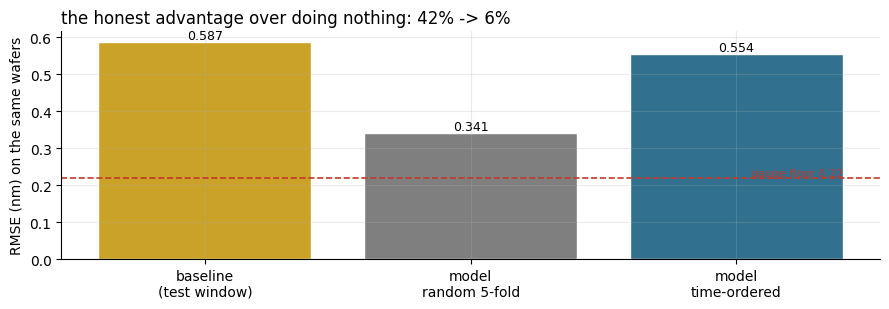

In [16]:
te = S_TIME[0][1]
p_time = PRED["time-ordered (58%)"]
p_rand = PRED["random 5-fold"]

base_te_rmse = float(np.sqrt(mean_squared_error(y[te], prev[te])))
rows = [
    {"quantity": "baseline, all 465 wafers", "RMSE (nm)": base_rmse, "R^2": base_r2},
    {"quantity": "baseline, test window only", "RMSE (nm)": base_te_rmse,
     "R^2": r2_score(y[te], prev[te])},
    {"quantity": "model, random 5-fold", "RMSE (nm)": score(y, p_rand)[1],
     "R^2": score(y, p_rand)[0]},
    {"quantity": "model, time-ordered split", "RMSE (nm)": score(y, p_time)[1],
     "R^2": score(y, p_time)[0]},
]
display(pd.DataFrame(rows).style.format({"RMSE (nm)": "{:.3f}", "R^2": "{:.3f}"})
        .hide(axis="index"))

adv_rand = 1 - score(y, p_rand)[1] / base_te_rmse
adv_time = 1 - score(y, p_time)[1] / base_te_rmse
print(f"advantage over the baseline, both measured on the same wafers:")
print(f"  random 5-fold : 1 - {score(y, p_rand)[1]:.3f} / {base_te_rmse:.3f} = {adv_rand:6.1%}")
print(f"  time-ordered  : 1 - {score(y, p_time)[1]:.3f} / {base_te_rmse:.3f} = {adv_time:6.1%}")

fig, ax = plt.subplots(figsize=(9, 3.2))
labels = ["baseline\n(test window)", "model\nrandom 5-fold", "model\ntime-ordered"]
vals = [base_te_rmse, score(y, p_rand)[1], score(y, p_time)[1]]
ax.bar(labels, vals, color=[GOLD, GREY, BLUE], edgecolor="white")
ax.axhline(sig_gauge, color=RED, ls="--", lw=1.2)
ax.annotate(f"gauge floor {sig_gauge:.2f}", (2.4, sig_gauge), ha="right", va="bottom",
            fontsize=8, color=RED)
for i, v in enumerate(vals):
    ax.annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("RMSE (nm) on the same wafers")
ax.set_title(f"the honest advantage over doing nothing: {adv_rand:.0%} -> {adv_time:.0%}",
             loc="left")
plt.tight_layout(); plt.show()

### The comparison that has to be made on the same wafers

The common mistake is to compare the model's time-ordered error against a baseline computed on all
465 wafers. Both numbers are real; they are computed on different wafers, so the comparison is
meaningless — and it is exactly the sloppiness this lecture is about. The baseline belongs on the
test window, because that is where the model was scored.

Do it properly and the advantage over a one-line predictor that ignores every sensor collapses from
tens of percent to a few. The model still wins. But an advantage that small has to be argued against
the maintenance burden of a deployed system — the pipeline, the monitoring, the retraining, the
person who owns it — rather than assumed to justify it.

Two overshoots to avoid. "The model is useless" is wrong: it beats the baseline, and it does it
without waiting hours for a measurement. "R² of 0.59 is still good" is also wrong, because it
answers a question nobody asked. The question is what the model adds over what you already have.

## P3 — Find the break
*Data: labelled wafers either side of the wet clean at run 600*

**The problem.** Train on wafers up to run 600, apply the model forward, and chart the residual.
Set the centre line and limits from **held-out pre-clean wafers** — never from the training
residuals. Say when the chart would have alarmed, and which run rule fired first.

In [17]:
res_all = y - m_pre.predict(X).ravel()          # m_pre was fitted on pre-clean runs only
mon = np.concatenate([pre[kk:], post])          # monitor: held-out pre-clean, then forward
r_mon, run_mon = res_all[mon], run[mon]

cl = float(r_ho.mean())
sigma_hat = sigma_from_mr(r_ho)                 # I-MR, from held-out data
ucl, lcl = cl + 3 * sigma_hat, cl - 3 * sigma_hat
print(f"limits from {len(r_ho)} held-out pre-clean wafers (never trained on):")
print(f"  centre line {cl:+.3f} nm, sigma_hat {sigma_hat:.3f} nm  ->  "
      f"limits {lcl:+.3f} to {ucl:+.3f} nm")
print(f"  for comparison, sigma from the TRAINING residuals would be "
      f"{sigma_from_mr(y[pre[:kk]] - m_pre.predict(X[pre[:kk]]).ravel()):.3f} nm "
      "— optimistically small, and every later point would breach it")

print(f"\nmean residual before the clean {r_ho.mean():+.3f} nm, "
      f"after {r_post.mean():+.3f} nm  (shift {r_post.mean()-r_ho.mean():+.3f} nm)")
out = np.where((r_mon > ucl) | (r_mon < lcl))[0]
print(f"points outside the three-sigma limits: {len(out)}, "
      f"{int((run_mon[out] > CLEAN_RUN).sum())} of them after run {CLEAN_RUN}")

rules = run_rules(r_mon, cl, sigma_hat)
WINDOW = {1: 1, 2: 3, 3: 5, 4: 8}          # how many points each rule looks at

first_after, false_pre = {}, {}
for r, hits in rules.items():
    w = WINDOW[r]
    clean_hits = [run_mon[i - 1] for i in hits if run_mon[i - w] > CLEAN_RUN]  # whole pattern post-clean
    first_after[r] = clean_hits[0] if clean_hits else None
    false_pre[r] = sum(1 for i in hits if run_mon[i - 1] <= CLEAN_RUN)
    print(f"  rule {r}: {len(hits):3d} signals in total, {false_pre[r]:2d} of them before the "
          f"clean (false alarms), first genuine signal at run "
          f"{first_after[r] if first_after[r] else '-'}")

fired = {r: v for r, v in first_after.items() if v is not None}
winner = min(fired, key=fired.get)
print(f"\nfirst rule to fire on wholly post-clean data: rule {winner}, at run {fired[winner]} "
      f"— {fired[winner] - CLEAN_RUN} runs after the event, "
      f"{int((run_mon > CLEAN_RUN).sum() and (run_mon[(run_mon > CLEAN_RUN)] <= fired[winner]).sum())} "
      "measured wafers later")
print(f"rule 1 alone would have waited until run {fired.get(1)}")

limits from 47 held-out pre-clean wafers (never trained on):
  centre line -0.041 nm, sigma_hat 0.364 nm  ->  limits -1.132 to +1.050 nm
  for comparison, sigma from the TRAINING residuals would be 0.183 nm — optimistically small, and every later point would breach it

mean residual before the clean -0.041 nm, after +0.168 nm  (shift +0.209 nm)
points outside the three-sigma limits: 26, 25 of them after run 600
  rule 1:  26 signals in total,  1 of them before the clean (false alarms), first genuine signal at run 660
  rule 2:  61 signals in total,  5 of them before the clean (false alarms), first genuine signal at run 660
  rule 3:  90 signals in total,  7 of them before the clean (false alarms), first genuine signal at run 613
  rule 4:  80 signals in total,  5 of them before the clean (false alarms), first genuine signal at run 620

first rule to fire on wholly post-clean data: rule 3, at run 613 — 13 runs after the event, 5 measured wafers later
rule 1 alone would have waited until

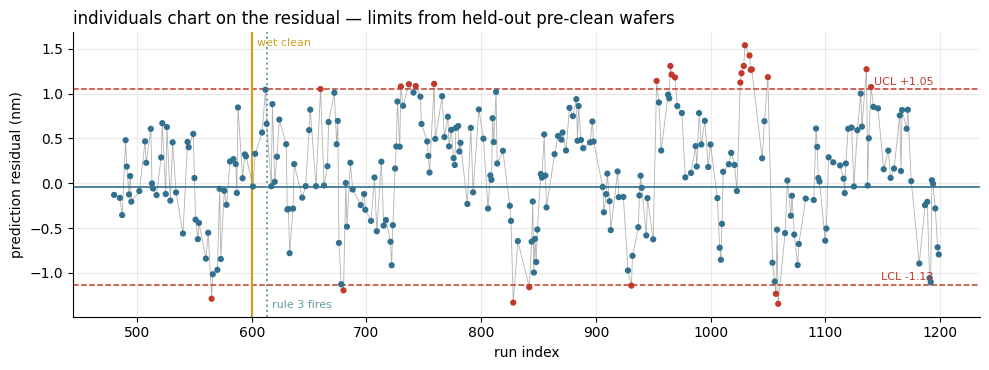

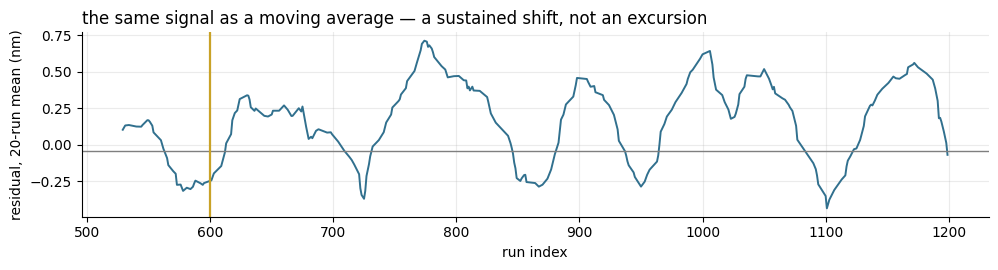

In [18]:
fig, ax = plt.subplots(figsize=(10, 3.8))
colors = np.where((r_mon > ucl) | (r_mon < lcl), RED, BLUE)
ax.scatter(run_mon, r_mon, s=12, c=colors, zorder=3)
ax.plot(run_mon, r_mon, lw=0.6, color=GREY, alpha=0.6, zorder=2)
ax.axhline(cl, color=BLUE, lw=1.2)
for lim, lab in ((ucl, "UCL"), (lcl, "LCL")):
    ax.axhline(lim, color=RED, ls="--", lw=1.1)
    ax.annotate(f"{lab} {lim:+.2f}", (run_mon.max(), lim), xytext=(-4, 3),
                textcoords="offset points", ha="right", fontsize=8, color=RED)
ax.axvline(CLEAN_RUN, color=GOLD, lw=1.6)
ax.annotate("wet clean", (CLEAN_RUN, ax.get_ylim()[1]), xytext=(4, -10),
            textcoords="offset points", fontsize=8, color=GOLD)
ax.axvline(fired[winner], color=TEAL, ls=":", lw=1.4)
ax.annotate(f"rule {winner} fires", (fired[winner], ax.get_ylim()[0]), xytext=(4, 6),
            textcoords="offset points", fontsize=8, color=TEAL)
ax.set_xlabel("run index"); ax.set_ylabel("prediction residual (nm)")
ax.set_title("individuals chart on the residual — limits from held-out pre-clean wafers",
             loc="left")
plt.tight_layout(); plt.show()

# what a manager sees: rolling mean residual
wm = pd.Series(r_mon, index=run_mon).rolling(20).mean()
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(wm.index, wm.values, lw=1.4, color=BLUE)
ax.axhline(cl, color=GREY, lw=1)
ax.axvline(CLEAN_RUN, color=GOLD, lw=1.6)
ax.set_xlabel("run index"); ax.set_ylabel("residual, 20-run mean (nm)")
ax.set_title("the same signal as a moving average — a sustained shift, not an excursion",
             loc="left")
plt.tight_layout(); plt.show()

### Where the limits come from, and what alarmed

The limits come from **held-out pre-clean wafers**: in control, from the same regime, and never
trained on. Setting them from training residuals is the classic error — those residuals are
optimistically small, so the limits are too tight and everything after the fit looks like a signal.
The printout shows both numbers so you can see the size of that mistake.

The failure here is a **sustained mean shift**, not a single excursion, and that is why the run
rules matter. Rule 1 — a point beyond three sigma — is the last to fire, because a shift of well
under one sigma rarely throws a single point that far. The rules built for a shift catch it dozens
of runs earlier: rule 4 (eight consecutive points on one side of the centre line) and rule 3 (four
of five beyond one sigma) both signal within a couple of dozen runs of the clean. Reporting *which*
rule fired first, and why that rule and not another, is the answer this problem is looking for — it
is the SPC unit's run rules applied to a model instead of a process.

The printout counts signals **before** the clean as well, and the sensitive rules produce some.
That is not a defect in the data, it is the trade-off: residuals are autocorrelated, so rules 2, 3
and 4 buy earlier detection at the cost of false alarms, exactly as they do on a process chart. Rule
1 is the quiet one and it is also the slow one. Which trade you take is an operational decision —
how much is a missed week of drift worth against an engineer chasing a signal that is not there.

**And the sentence that matters: the process never changed.** The chamber was healthy, the wafers
were in specification, the CD-SEM was fine. What went out of control was the model. That is the
whole argument for charting the residual separately from the process — the process chart would have
shown nothing worth acting on, because there was nothing wrong with the process.

## P4 — Budget the error
*Data: the four splits from P1, plus the gauge sigma from HW1 P5*

**The problem.** Split the honest RMSE into the gauge contribution and the model's own. Then answer
the question a manager will ask: how much of what is left is worth chasing, and what would you do to
chase it?

split,total RMSE (nm),gauge (nm),model's own (nm),gauge share of MSE
random 5-fold,0.341,0.220,0.260,42%
lot-grouped 5-fold,0.498,0.220,0.447,19%
leave-one-chamber-out,0.532,0.220,0.484,17%
time-ordered (58%),0.554,0.220,0.509,16%


of the honest 0.554 nm, 0.220 nm is untouchable and 0.509 nm belongs to the model
a perfect model would reach 0.220 nm — an improvement of 60% from where we are


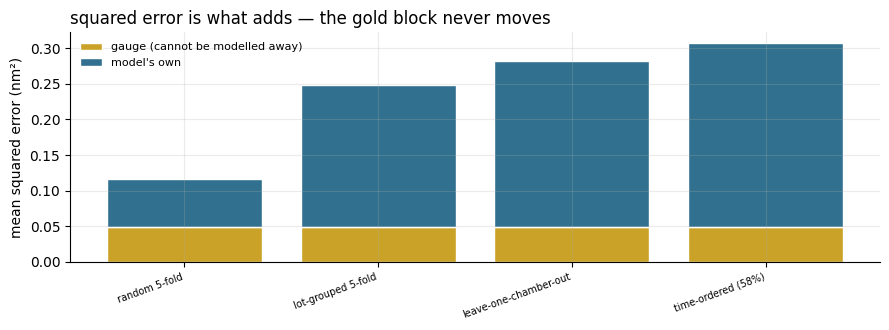

In [19]:
budget = pd.DataFrame({"split": four["split"], "total RMSE (nm)": four["RMSE (nm)"]})
budget["gauge (nm)"] = sig_gauge
budget["model's own (nm)"] = np.sqrt(np.maximum(budget["total RMSE (nm)"] ** 2 - sig_gauge ** 2, 0))
budget["gauge share of MSE"] = sig_gauge ** 2 / budget["total RMSE (nm)"] ** 2
display(budget.style.format({"total RMSE (nm)": "{:.3f}", "gauge (nm)": "{:.3f}",
                             "model's own (nm)": "{:.3f}", "gauge share of MSE": "{:.0%}"})
        .hide(axis="index"))

honest = float(budget.loc[budget.split == "time-ordered (58%)", "total RMSE (nm)"].iloc[0])
own = float(budget.loc[budget.split == "time-ordered (58%)", "model's own (nm)"].iloc[0])
print(f"of the honest {honest:.3f} nm, {sig_gauge:.3f} nm is untouchable and "
      f"{own:.3f} nm belongs to the model")
print(f"a perfect model would reach {sig_gauge:.3f} nm — an improvement of "
      f"{1 - sig_gauge/honest:.0%} from where we are")

fig, ax = plt.subplots(figsize=(9, 3.4))
mse_g = np.full(4, sig_gauge ** 2)
mse_m = budget["total RMSE (nm)"] ** 2 - mse_g
ax.bar(range(4), mse_g, color=GOLD, edgecolor="white", label="gauge (cannot be modelled away)")
ax.bar(range(4), mse_m, bottom=mse_g, color=BLUE, edgecolor="white", label="model's own")
ax.set_xticks(range(4))
ax.set_xticklabels(budget["split"], rotation=20, ha="right", fontsize=7)
ax.set_ylabel("mean squared error (nm²)")
ax.set_title("squared error is what adds — the gold block never moves", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

refits: 3 (at runs [np.int64(698), np.int64(800), np.int64(1000)])
per-chamber residual bias in the training window: A +0.008 nm, B -0.008 nm
frozen model on the test window          0.554 nm
retrained at each chamber event          0.522 nm  (-5.8%)
frozen model + per-chamber offset        0.555 nm  (+0.1%)
one model per chamber                    0.784 nm  (+41.4%)
abstain on the least certain 30%         0.489 nm  (-11.8% on the 70% it answers)


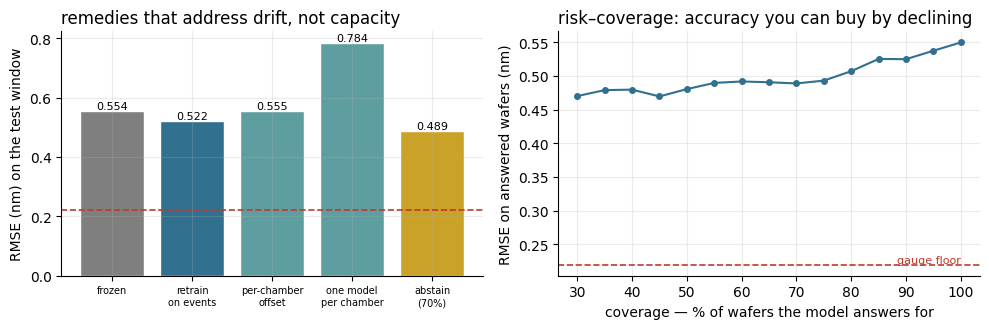

In [20]:
# ---- three remedies, all aimed at drift rather than at model capacity
Xte, yte = X[te], y[te]

# (a) frozen model, for reference
frozen = pls().fit(X[idx[:CUT]], y[idx[:CUT]])
rmse_frozen = float(np.sqrt(mean_squared_error(yte, frozen.predict(Xte).ravel())))

# (b) retrain at every chamber event, on everything available up to that event
ev_runs = [r for r in EVENTS.run_index if run[CUT] < r < run[-1]]
fit_to = np.array([max([r for r in ev_runs if r <= rr], default=run[CUT - 1]) for rr in run[te]])
pred_rt = np.empty(len(te))
for cutoff in np.unique(fit_to):                 # one refit per event, not per wafer
    tr = idx[run <= cutoff]
    sel = fit_to == cutoff
    pred_rt[sel] = pls().fit(X[tr], y[tr]).predict(Xte[sel]).ravel()
rmse_retrain = float(np.sqrt(mean_squared_error(yte, pred_rt)))
print(f"refits: {len(np.unique(fit_to))} (at runs {sorted(set(np.unique(fit_to)))})")

# (c) a per-chamber offset, estimated on the training window only
tr_i = idx[:CUT]
off = {c: float((y[tr_i][cham[tr_i] == c]
                 - frozen.predict(X[tr_i][cham[tr_i] == c]).ravel()).mean())
       for c in ("A", "B")}
pred_off = frozen.predict(Xte).ravel() + np.array([off[c] for c in cham[te]])
rmse_offset = float(np.sqrt(mean_squared_error(yte, pred_off)))
print("per-chamber residual bias in the training window: "
      + ", ".join(f"{c} {v:+.3f} nm" for c, v in off.items()))

# (c2) one model per chamber instead of one model
pred_per = np.empty(len(te))
for c in ("A", "B"):
    fit = pls().fit(X[tr_i][cham[tr_i] == c], y[tr_i][cham[tr_i] == c])
    sel = cham[te] == c
    pred_per[sel] = fit.predict(Xte[sel]).ravel()
rmse_perchamber = float(np.sqrt(mean_squared_error(yte, pred_per)))

# (d) let the model decline: risk-coverage using distance in PLS score space
sc_tr = frozen[:-1].transform(X[idx[:CUT]])
T_tr = frozen[-1].transform(sc_tr)
T_te = frozen[-1].transform(frozen[:-1].transform(Xte))
cov_inv = np.linalg.pinv(np.cov(T_tr.T))
t2 = np.einsum("ij,jk,ik->i", T_te - T_tr.mean(0), cov_inv, T_te - T_tr.mean(0))
order = np.argsort(t2)
res_te = yte - frozen.predict(Xte).ravel()
covs = np.arange(0.3, 1.001, 0.05)
rc = [float(np.sqrt((res_te[order[:max(1, int(c*len(te)))]] ** 2).mean())) for c in covs]
rmse_70 = rc[int(np.argmin(np.abs(covs - 0.70)))]

print(f"frozen model on the test window          {rmse_frozen:.3f} nm")
print(f"retrained at each chamber event          {rmse_retrain:.3f} nm  "
      f"({rmse_retrain/rmse_frozen-1:+.1%})")
print(f"frozen model + per-chamber offset        {rmse_offset:.3f} nm  "
      f"({rmse_offset/rmse_frozen-1:+.1%})")
print(f"one model per chamber                    {rmse_perchamber:.3f} nm  "
      f"({rmse_perchamber/rmse_frozen-1:+.1%})")
print(f"abstain on the least certain 30%         {rmse_70:.3f} nm  "
      f"({rmse_70/rmse_frozen-1:+.1%} on the 70% it answers)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
labs = ["frozen", "retrain\non events", "per-chamber\noffset", "one model\nper chamber",
        "abstain\n(70%)"]
vals = [rmse_frozen, rmse_retrain, rmse_offset, rmse_perchamber, rmse_70]
axes[0].bar(labs, vals, color=[GREY, BLUE, TEAL, TEAL, GOLD], edgecolor="white")
axes[0].axhline(sig_gauge, color=RED, ls="--", lw=1.2)
for i, v in enumerate(vals):
    axes[0].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel("RMSE (nm) on the test window")
axes[0].set_title("remedies that address drift, not capacity", loc="left")
axes[0].tick_params(axis="x", labelsize=7)

axes[1].plot(covs * 100, rc, "o-", ms=4, color=BLUE)
axes[1].axhline(sig_gauge, color=RED, ls="--", lw=1.2)
axes[1].annotate("gauge floor", (100, sig_gauge), ha="right", va="bottom", fontsize=8, color=RED)
axes[1].set_xlabel("coverage — % of wafers the model answers for")
axes[1].set_ylabel("RMSE on answered wafers (nm)")
axes[1].set_title("risk–coverage: accuracy you can buy by declining", loc="left")
plt.tight_layout(); plt.show()

### How much is worth chasing

Variances add, so the split is exact: of the honest error, a fixed piece belongs to the CD-SEM and
cannot be modelled away at any price, and the rest belongs to the model. That gives modelling effort
a target and a ceiling in the same sentence — and it is an argument you can take to somebody who
controls a budget, because it came out of a variance decomposition rather than a preference.

**What to chase, and what not to.** The gap that opened between the lot-grouped and time-ordered
numbers in P1 is *drift*, not *capacity*. So the remedies that pay are the ones aimed at drift:

- **Retrain on chamber events** rather than freezing the model or refreshing it on a calendar. The
  events file has timestamps; the model should be refitted when the process moves, not when the
  month turns.
- **Per-chamber handling.** Two versions are run above: a constant offset correction, and one
  model per chamber. Read the numbers before believing either — if the offset correction buys
  nothing, the chamber difference was not a constant bias in the first place, and the honest
  conclusion is that leave-one-chamber-out exposed a *coefficient* difference rather than an
  intercept. Fitting one model per chamber also halves the labels each model gets, which on 465
  measurements is a real cost.
- **An abstain option.** The risk–coverage curve is the honest way to buy accuracy: answer for the
  wafers the model is confident about and send the rest to metrology. Coverage is a dial the process
  owner sets from the cost of being wrong, not a percentile you pick because it looks tidy.

A deeper network is the wrong answer here, and should be marked down unless it comes with a plan for
more labels: 465 measurements is the binding constraint, and no architecture fixes that.

## P5 — Tune the controller
*Data: the honest RMSE from P1 and the gauge sigma from HW1 P5*

**The problem.** A run-to-run controller uses an EWMA gain of λ = 0.30 on real CD-SEM measurements.
What gain should it use on virtual metrology predictions? One line of arithmetic, and the reasoning
matters more than the number.

ratio  = 0.554 / 0.220 = 2.52
lambda = 0.30 / (1 + 2.52^2) = 0.041   <- the honest setting

with the leaky RMSE of 0.341 nm you would have set 0.088 — 2.2x too aggressive
that is the evaluation error from P1 propagating into a controller setting, and from there into the process


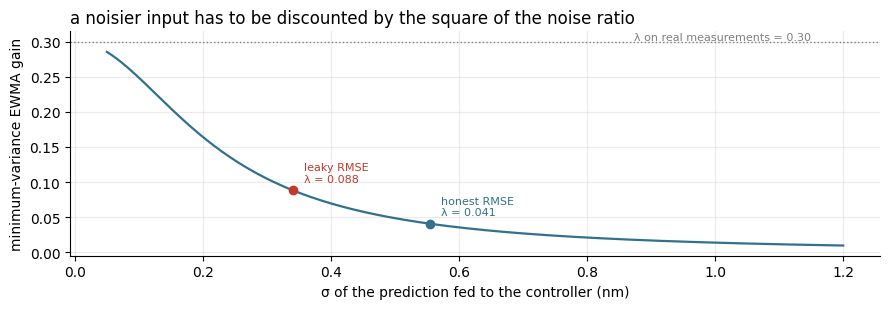

In [21]:
LAMBDA_METROLOGY = 0.30

def lam_vm(sigma_vm, sigma_gauge=None, lam=LAMBDA_METROLOGY):
    "Minimum-variance EWMA gain, discounted by the square of the noise ratio."
    sg = sigma_gauge if sigma_gauge is not None else sig_gauge
    return lam / (1 + (sigma_vm / sg) ** 2)

honest_rmse = float(four.loc[four.split == "time-ordered (58%)", "RMSE (nm)"].iloc[0])
optim_rmse  = float(four.loc[four.split == "random 5-fold", "RMSE (nm)"].iloc[0])

print(f"ratio  = {honest_rmse:.3f} / {sig_gauge:.3f} = {honest_rmse/sig_gauge:.2f}")
print(f"lambda = {LAMBDA_METROLOGY:.2f} / (1 + {honest_rmse/sig_gauge:.2f}^2) = "
      f"{lam_vm(honest_rmse):.3f}   <- the honest setting")
print(f"\nwith the leaky RMSE of {optim_rmse:.3f} nm you would have set "
      f"{lam_vm(optim_rmse):.3f} — {lam_vm(optim_rmse)/lam_vm(honest_rmse):.1f}x too aggressive")
print(f"that is the evaluation error from P1 propagating into a controller setting, "
      f"and from there into the process")

grid = np.linspace(0.05, 1.2, 200)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(grid, [lam_vm(s) for s in grid], lw=1.6, color=BLUE)
ax.axhline(LAMBDA_METROLOGY, color=GREY, ls=":", lw=1)
ax.annotate("λ on real measurements = 0.30", (1.15, LAMBDA_METROLOGY), ha="right", va="bottom",
            fontsize=8, color=GREY)
for s, c, lab in ((honest_rmse, BLUE, "honest RMSE"), (optim_rmse, RED, "leaky RMSE")):
    ax.plot([s], [lam_vm(s)], "o", color=c, ms=6)
    ax.annotate(f"{lab}\nλ = {lam_vm(s):.3f}", (s, lam_vm(s)), xytext=(8, 6),
                textcoords="offset points", fontsize=8, color=c)
ax.set_xlabel("σ of the prediction fed to the controller (nm)")
ax.set_ylabel("minimum-variance EWMA gain")
ax.set_title("a noisier input has to be discounted by the square of the noise ratio", loc="left")
plt.tight_layout(); plt.show()

### The reasoning

$$\lambda_{\text{VM}}=\frac{\lambda_{\text{metrology}}}{1+\left(\sigma_{\text{VM}}/\sigma_{\text{gauge}}\right)^2}$$

Two points, and they are the marks.

**Use the honest RMSE.** Plugging in the leaky number gives a gain several times too aggressive. That
is the practical consequence of P1: an evaluation mistake does not stay in the notebook, it
propagates into a controller setting and injects variation into a process that was running fine.

**Name what happens if you skip the discount.** The controller starts chasing prediction noise. Every
prediction error becomes a recipe correction, and the corrections themselves become a source of
variation — the tampering experiment from the SPC unit, with a model in the role of the over-eager
operator. Discounting the gain is what keeps the controller listening to the process rather than to
the model's mistakes.

## P6 — Propose a deployment
*Two pages, marked on reasoning rather than length*

**The problem.** Propose how you would actually deploy this model. Six elements:

1. **Which use** — from the four levels of increasing risk: chart it; feed the run-to-run
   controller; choose what to measure; release material on a prediction. Argue from the honest
   error, not from the one you wish you had.
2. **Abstain threshold** — and where the number came from.
3. **Residual chart** — subgroup, where the limits come from, which run rules, what each signal
   means operationally.
4. **Retrain trigger** — what fires a refit.
5. **Rollback** — what it means concretely, and who gets paged.
6. **What you gave up** — the strongest submissions propose a *smaller* deployment than they could
   have, and say why.

The cell below assembles the evidence pack you should be arguing from.

In [22]:
pack = pd.DataFrame([
    ("honest RMSE (time-ordered)", f"{honest_rmse:.3f} nm"),
    ("gauge sigma (CD-SEM)", f"{sig_gauge:.3f} nm"),
    ("ratio to gauge", f"{honest_rmse/sig_gauge:.1f}x"),
    ("model's own error", f"{own:.3f} nm"),
    ("baseline on the same wafers", f"{base_te_rmse:.3f} nm"),
    ("honest advantage over baseline", f"{adv_time:.1%}"),
    ("specification window", f"{USL-LSL:.1f} nm"),
    ("honest error as % of window", f"{100*honest_rmse/(USL-LSL):.1f}%"),
    ("R² ceiling set by the gauge", f"{r2_ceiling:.3f}"),
    ("RMSE at 70% coverage", f"{rmse_70:.3f} nm"),
    ("residual shift at the wet clean", f"{r_post.mean()-r_ho.mean():+.3f} nm"),
    ("first run rule to fire after it", f"rule {winner}, {fired[winner]-CLEAN_RUN} runs later"),
    ("EWMA gain for the controller", f"{lam_vm(honest_rmse):.3f} (vs 0.30 on real metrology)"),
    ("labelled wafers available", f"{n} of {len(CLEAN_FEAT)} completed runs"),
], columns=["quantity", "value"])
display(pack.style.hide(axis="index"))

print("Where this model sits: at "
      f"{honest_rmse/sig_gauge:.1f}x the gauge it is in the 'comparable to the gauge' band — "
      "monitoring, adaptive sampling and a discounted controller gain are defensible; "
      "releasing material on a prediction is not.")

quantity,value
honest RMSE (time-ordered),0.554 nm
gauge sigma (CD-SEM),0.220 nm
ratio to gauge,2.5x
model's own error,0.509 nm
baseline on the same wafers,0.587 nm
honest advantage over baseline,5.6%
specification window,4.0 nm
honest error as % of window,13.9%
R² ceiling set by the gauge,0.947
RMSE at 70% coverage,0.489 nm


Where this model sits: at 2.5x the gauge it is in the 'comparable to the gauge' band — monitoring, adaptive sampling and a discounted controller gain are defensible; releasing material on a prediction is not.


### What a strong submission contains

| element | what a good answer looks like |
|---|---|
| **Which use** | Levels 1–3, argued from the honest error and its ratio to the gauge. At this ratio, a case for dispositioning material without measuring has to be exceptional — and the burden of proof is on the proposer. |
| **Abstain threshold** | Derived from the cost of being wrong and the margin to the nearest specification limit, referencing the risk–coverage curve in P4 — not picked as a round percentile. |
| **Residual chart** | Individuals and moving range on the prediction residual. Limits from a held-out in-control window. Named run rules, and what each signal means operationally. |
| **Retrain trigger** | Chamber events from `vm_events.csv`, recipe and product changes, a run rule on the residual — plus a slow scheduled refresh as a floor. |
| **Rollback** | The previous model one command away, a documented fallback to the fixed sampling plan, and a named owner who gets paged. |
| **What you gave up** | A deliberately smaller deployment than the numbers would allow, with the reason stated. |

**The mark I am really looking for** is a limitation you found in your *own* proposal. The obvious
one: if the model feeds the controller, the controller corrects the process, and the corrections
erode the very variation the model was trained on — so the training signal decays and the model
looks better than it is. The cheap fix is to log the controller correction and train on the
uncorrected quantity. Recognising a problem you created yourself is the skill this project tests.

---

## Marking guidance

| | marks | full credit needs |
|---|---|---|
| **HW1 P1** | 10 | Features rebuilt from the traces; the mismatch explained as a definition problem, not a bug |
| **HW1 P2** | 10 | Baseline computed *first*; all four models cross-validated the same way |
| **HW1 P3** | 10 | A component count chosen by CV, with the one-standard-error argument written down |
| **HW1 P4** | 10 | Top coefficients by block, and the implication of the lot-level block named |
| **HW1 P5** | 10 | Floor and ceiling *derived* from the gauge study, not quoted |
| **HW1 P6** | 5 | The stuck sensor and the run found, with a rolling window |
| **HW2 P1** | 20 | All four numbers, plus lot leakage and temporal leakage named as *separate* mechanisms |
| **HW2 P2** | 20 | Baseline on the test window only; the collapse in advantage stated |
| **HW2 P3** | 20 | Limits from held-out data; the run rule that fires first identified; "the process never changed" |
| **HW2 P4** | 15 | Correct variance decomposition; remedies aimed at drift rather than capacity |
| **HW2 P5** | 10 | λ computed from the honest RMSE, with the tampering consequence named |
| **HW2 P6** | 15 | All six elements; credit for identifying a limitation in the proposal itself |

HW2 P1 and P2 carry the most weight, because together they are the lecture. A student who can
compute four splits but cannot explain why they differ has done the mechanics without the idea.